In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:

dfPayments = pd.read_csv("archive/olist_order_payments_dataset.csv")
dfProducts = pd.read_csv("archive/olist_products_dataset.csv")
dfOrders = pd.read_csv("archive/olist_orders_dataset.csv")
dfOrdersItens = pd.read_csv("archive/olist_order_items_dataset.csv")

In [ ]:
#Agrupando as tabelas que serão utlizadas pelas foreign key

df = pd.merge(dfOrders, dfOrdersItens, on='order_id', how='inner')
df = pd.merge(df, dfProducts, on='product_id', how='inner')
df = pd.merge(df, dfPayments, on='order_id', how='inner')
df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,178.0,1.0,400.0,19.0,13.0,19.0,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,232.0,1.0,420.0,24.0,19.0,21.0,1,credit_card,3,179.12


In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 117601 entries, 0 to 117600
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117601 non-null  str    
 1   customer_id                    117601 non-null  str    
 2   order_status                   117601 non-null  str    
 3   order_purchase_timestamp       117601 non-null  str    
 4   order_approved_at              117586 non-null  str    
 5   order_delivered_carrier_date   116356 non-null  str    
 6   order_delivered_customer_date  115034 non-null  str    
 7   order_estimated_delivery_date  117601 non-null  str    
 8   order_item_id                  117601 non-null  int64  
 9   product_id                     117601 non-null  str    
 10  seller_id                      117601 non-null  str    
 11  shipping_limit_date            117601 non-null  str    
 12  price                          117601 non

In [ ]:
#Removendo colunas que não irão ser utilizadas

df = df.drop(columns=[
    'order_id', 'product_id', 'seller_id', 'customer_id',
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'payment_sequential', 'payment_installments',
    'product_name_lenght', 'product_description_lenght',
    'product_photos_qty', 'shipping_limit_date', 'order_status', 'order_item_id', 'product_category_name'
], errors='ignore')
df.head()

,price,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_type,payment_value
0,29.99,8.72,500.0,19.0,8.0,13.0,credit_card,18.12
1,29.99,8.72,500.0,19.0,8.0,13.0,voucher,2.00
2,29.99,8.72,500.0,19.0,8.0,13.0,voucher,18.59
3,118.70,22.76,400.0,19.0,13.0,19.0,boleto,141.46
4,159.90,19.22,420.0,24.0,19.0,21.0,credit_card,179.12


In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 117601 entries, 0 to 117600
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   price              117601 non-null  float64
 1   freight_value      117601 non-null  float64
 2   product_weight_g   117581 non-null  float64
 3   product_length_cm  117581 non-null  float64
 4   product_height_cm  117581 non-null  float64
 5   product_width_cm   117581 non-null  float64
 6   payment_type       117601 non-null  str    
 7   payment_value      117601 non-null  float64
dtypes: float64(7), str(1)
memory usage: 7.2 MB


In [53]:
df = df.dropna(axis=0)
df.info()

<class 'pandas.DataFrame'>
Index: 117581 entries, 0 to 117600
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   price              117581 non-null  float64
 1   freight_value      117581 non-null  float64
 2   product_weight_g   117581 non-null  float64
 3   product_length_cm  117581 non-null  float64
 4   product_height_cm  117581 non-null  float64
 5   product_width_cm   117581 non-null  float64
 6   payment_type       117581 non-null  str    
 7   payment_value      117581 non-null  float64
dtypes: float64(7), str(1)
memory usage: 8.1 MB


In [54]:
df['payment_type'].unique()

<StringArray>
['credit_card', 'voucher', 'boleto', 'debit_card']
Length: 4, dtype: str

In [56]:
#transformando Variaveis categóricas e, numéricas

df['payment_type'] = df['payment_type'].replace({'credit_card': 0, 'voucher': 1, 'boleto': 2, 'debit_card': 3 })
df.head()

,price,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_type,payment_value
0,29.99,8.72,500.0,19.0,8.0,13.0,0,18.12
1,29.99,8.72,500.0,19.0,8.0,13.0,1,2.00
2,29.99,8.72,500.0,19.0,8.0,13.0,1,18.59
3,118.70,22.76,400.0,19.0,13.0,19.0,2,141.46
4,159.90,19.22,420.0,24.0,19.0,21.0,0,179.12


## Exploratory Data Analysis (EDA)

In [ ]:
#estatisticas descritivas sobre o dataset
df.describe().round(2)

,price,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_value
count,117581.00,117581.00,117581.00,117581.00,117581.00,117581.00,117581.00
mean,120.82,20.05,2114.31,30.26,16.63,23.07,172.69
std,184.42,15.86,3788.80,16.19,13.46,11.75,267.56
min,0.85,0.00,0.00,7.00,2.00,6.00,0.00
25%,39.90,13.08,300.00,18.00,8.00,15.00,60.90
50%,74.90,16.30,700.00,25.00,13.00,20.00,108.26
75%,134.90,21.19,1800.00,38.00,20.00,30.00,189.30
max,6735.00,409.68,40425.00,105.00,105.00,118.00,13664.08


C:\Users\Aluno\AppData\Local\Temp\ipykernel_3748\1800023948.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


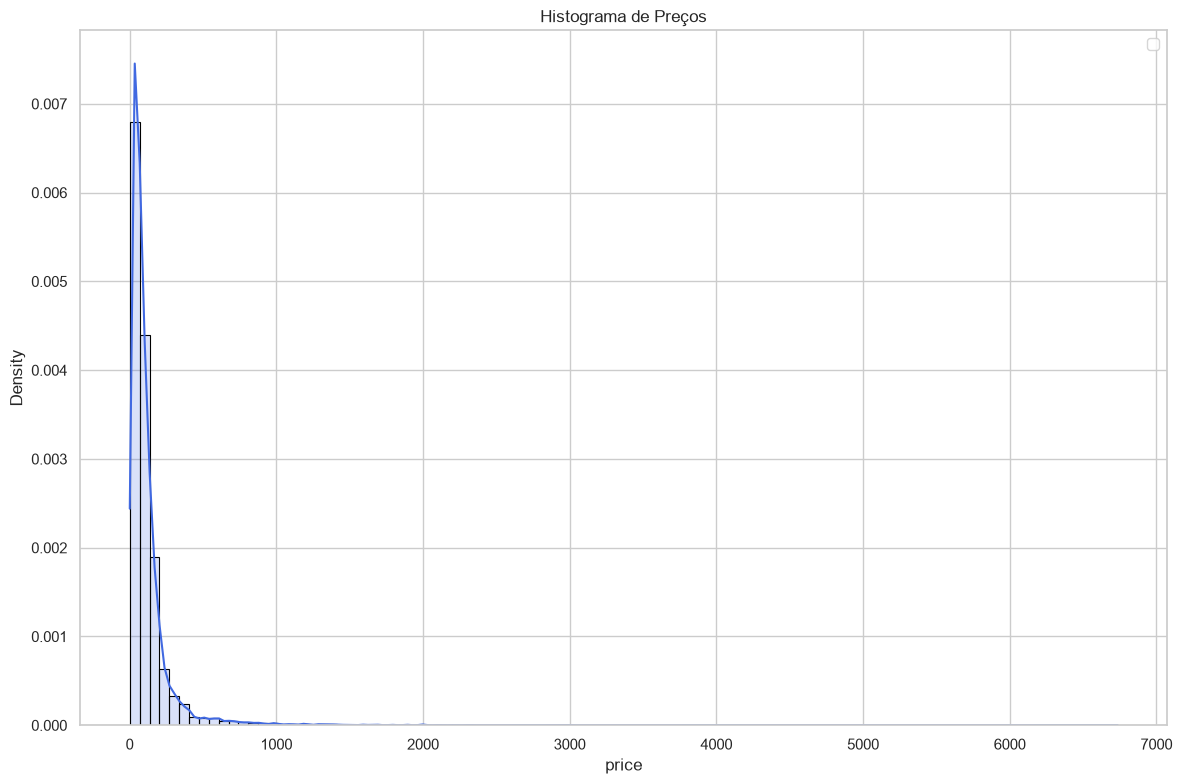

In [ ]:
sns.set_theme(style='whitegrid')

plt.figure(figsize=(12,8));

sns.histplot(df['price'], bins=100, stat='density', color='royalblue', alpha=0.5, edgecolor='black', linewidth=0.8, kde=True)

plt.title('Histograma de Preços');
plt.legend()
plt.tight_layout()
plt.show()